In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("/content/car data.csv")

In [4]:
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [6]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [9]:
label_encoder = LabelEncoder()

categorical_columns = ['Fuel_Type', 'Selling_type', 'Transmission']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [10]:
X = df.drop(['Selling_Price', 'Car_Name'], axis=1)
y = df['Selling_Price']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)



Model Evaluation
------------------
MAE : 1.2219323621752294
MSE : 3.5315798889713164
RMSE: 1.8792498207985324
R2 Score: 0.8466902419662664


In [15]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted")
print(comparison.head())


Actual vs Predicted
   Actual Price  Predicted Price
0          0.35         2.965630
1         10.11         8.300858
2          4.95         6.057828
3          0.15        -1.467368
4          6.95         9.257057


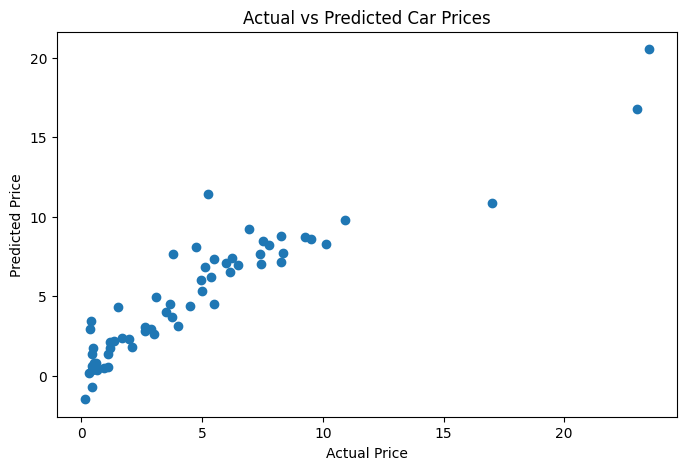

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [22]:
new_car = pd.DataFrame({
    'Year': [2018],
    'Present_Price': [7.5],
    'Driven_kms': [30000],  # Corrected column name from 'Kms_Driven' to 'Driven_kms'
    'Fuel_Type': [1],
    'Selling_type': [0],
    'Transmission': [1],
    'Owner': [0]
})
predicted_price = model.predict(new_car)

print("\nPredicted Car Price:", predicted_price[0])


Predicted Car Price: 7.563197405737128
